In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 15)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='Set2')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df_raw = pd.read_csv('netflix_titles.csv')

print(f"Rows   : {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

Rows   : 8,807
Columns: 12


In [3]:
df_raw.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [4]:
print("Data Types:")
print(df_raw.dtypes)

Data Types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [5]:
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)

print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}).to_string())

              Missing Count  Missing %
show_id                   0       0.00
type                      0       0.00
title                     0       0.00
director               2634      29.91
cast                    825       9.37
country                 831       9.44
date_added               10       0.11
release_year              0       0.00
rating                    4       0.05
duration                  3       0.03
listed_in                 0       0.00
description               0       0.00


In [6]:
print(f"Duplicate rows: {df_raw.duplicated().sum():,}")
print(f"Unique show_id values: {df_raw['show_id'].nunique():,}")

Duplicate rows: 0
Unique show_id values: 8,807


In [7]:
print("Content Types:")
print(df_raw['type'].value_counts())
print()
print("Sample ratings:")
print(df_raw['rating'].value_counts().head(8))
print()
print("Sample duration values:")
print(df_raw['duration'].dropna().head(8).tolist())

Content Types:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Sample ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
Name: count, dtype: int64

Sample duration values:
['90 min', '2 Seasons', '1 Season', '1 Season', '2 Seasons', '1 Season', '91 min', '125 min']


In [8]:
df = df_raw.copy()
print("Working copy created.")

Working copy created.


In [9]:
df['director'] = df['director'].fillna('Not Listed')
df['cast']     = df['cast'].fillna('Not Listed')

print(f"Missing directors: {df['director'].isnull().sum()}")
print(f"Missing cast     : {df['cast'].isnull().sum()}")

Missing directors: 0
Missing cast     : 0


In [10]:
df['country'] = df['country'].fillna('Unknown')

print(f"Missing country: {df['country'].isnull().sum()}")

Missing country: 0


In [11]:
before = len(df)

df = df.dropna(subset=['rating', 'duration', 'date_added'])

after = len(df)

print(f"Rows before: {before:,}")
print(f"Rows after : {after:,}")
print(f"Rows dropped: {before - after:,}")

Rows before: 8,807
Rows after : 8,790
Rows dropped: 17


In [12]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')

df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

print(f"date_added type: {df['date_added'].dtype}")
print(f"Sample:")
print(df[['date_added', 'year_added', 'month_added']].head())

date_added type: datetime64[us]
Sample:
  date_added  year_added month_added
0 2021-09-25        2021   September
1 2021-09-24        2021   September
2 2021-09-24        2021   September
3 2021-09-24        2021   September
4 2021-09-24        2021   September


In [13]:
df['type']    = df['type'].str.strip().str.title()
df['country'] = df['country'].str.strip().str.title()
df['rating']  = df['rating'].str.strip().str.upper()
df['title']   = df['title'].str.strip()

print("Sample type values  :", df['type'].unique().tolist())
print("Sample rating values:", df['rating'].value_counts().head(5).index.tolist())

Sample type values  : ['Movie', 'Tv Show']
Sample rating values: ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13']


In [14]:
import re

def extract_duration(row):
    val = str(row['duration'])
    nums = re.findall(r'\d+', val)
    if not nums:
        return np.nan, np.nan
    n = int(nums[0])
    if row['type'] == 'Movie':
        return n, np.nan
    else:
        return np.nan, n

df[['duration_mins', 'duration_seasons']] = df.apply(
    extract_duration, axis=1, result_type='expand')

print("Movies - duration_mins sample:")
print(df[df['type']=='Movie']['duration_mins'].describe().round(2))
print()
print("TV Shows - duration_seasons sample:")
print(df[df['type']=='Tv Show']['duration_seasons'].describe().round(2))

Movies - duration_mins sample:
count    6126.00
mean       99.58
std        28.28
min         3.00
25%        87.00
50%        98.00
75%       114.00
max       312.00
Name: duration_mins, dtype: float64

TV Shows - duration_seasons sample:
count    2664.00
mean        1.75
std         1.55
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        17.00
Name: duration_seasons, dtype: float64


In [15]:
summary = pd.DataFrame({
    'Issue Found': [
        'Missing director (2,634 rows)',
        'Missing cast (825 rows)',
        'Missing country (831 rows)',
        'Missing rating, duration, date_added (17 rows)',
        'date_added stored as text',
        'No numeric duration column',
        'Inconsistent text casing'
    ],
    'Action Taken': [
        'Filled with "Not Listed"',
        'Filled with "Not Listed"',
        'Filled with "Unknown"',
        'Rows dropped — too few to fill accurately',
        'Converted to datetime; year_added and month_added extracted',
        'duration_mins and duration_seasons created',
        'Applied strip, title and upper case'
    ]
})

print(summary.to_string(index=False))

                                   Issue Found                                                Action Taken
                 Missing director (2,634 rows)                                    Filled with "Not Listed"
                       Missing cast (825 rows)                                    Filled with "Not Listed"
                    Missing country (831 rows)                                       Filled with "Unknown"
Missing rating, duration, date_added (17 rows)                   Rows dropped — too few to fill accurately
                     date_added stored as text Converted to datetime; year_added and month_added extracted
                    No numeric duration column                  duration_mins and duration_seasons created
                      Inconsistent text casing                         Applied strip, title and upper case


In [16]:
df.to_csv('netflix_cleaned.csv', index=False)
print(f"Saved! Clean dataset has {len(df):,} rows.")

Saved! Clean dataset has 8,790 rows.


In [17]:
print("=== NETFLIX KEY METRICS ===")
print(f"Total Titles      : {len(df):,}")
print(f"Movies            : {(df['type']=='Movie').sum():,}")
print(f"TV Shows          : {(df['type']=='Tv Show').sum():,}")
print(f"Countries         : {df[df['country']!='Unknown']['country'].nunique():,}")
print(f"Unique Ratings    : {df['rating'].nunique():,}")
print(f"Release Year Range: {int(df['release_year'].min())} – {int(df['release_year'].max())}")
print(f"Date Added Range  : {df['date_added'].min().date()} – {df['date_added'].max().date()}")
print(f"Avg Movie Runtime : {df[df['type']=='Movie']['duration_mins'].mean():.0f} mins")

=== NETFLIX KEY METRICS ===
Total Titles      : 8,790
Movies            : 6,126
TV Shows          : 2,664
Countries         : 748
Unique Ratings    : 14
Release Year Range: 1925 – 2021
Date Added Range  : 2008-01-01 – 2021-09-25
Avg Movie Runtime : 100 mins


In [18]:
type_counts = df['type'].value_counts()

print("Content Type Distribution:")
print(type_counts.to_string())
print()
print(f"Movie share  : {type_counts['Movie']/len(df)*100:.1f}%")
print(f"TV Show share: {type_counts['Tv Show']/len(df)*100:.1f}%")

Content Type Distribution:
type
Movie      6126
Tv Show    2664

Movie share  : 69.7%
TV Show share: 30.3%


In [19]:
by_year = (df.groupby('year_added')
           .size()
           .sort_index())

print("Titles added per year:")
print(by_year.to_string())

Titles added per year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498


In [20]:
top_countries = (df[df['country'] != 'Unknown']['country']
                 .value_counts()
                 .head(10))

print("Top 10 Content Producing Countries:")
print(top_countries.to_string())

Top 10 Content Producing Countries:
country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106


In [21]:
ratings = df['rating'].value_counts()

print("Content Ratings:")
print(ratings.to_string())
print()
tv_ma = ratings['TV-MA'] / len(df) * 100
tv_14 = ratings['TV-14'] / len(df) * 100
print(f"TV-MA + TV-14 combined: {tv_ma + tv_14:.1f}% of all content")

Content Ratings:
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3

TV-MA + TV-14 combined: 61.0% of all content


In [22]:
all_genres = df['listed_in'].str.split(', ').explode()
genre_counts = all_genres.value_counts().head(15)

print("Top 15 Genres on Netflix:")
print(genre_counts.to_string())

Top 15 Genres on Netflix:
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  573
Crime TV Shows               469
Kids' TV                     448
Docuseries                   394


In [23]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_adds = df['month_added'].value_counts().reindex(month_order)

print("Titles added per month:")
print(monthly_adds.to_string())

Titles added per month:
month_added
January      737
February     562
March        741
April        763
May          632
June         728
July         827
August       754
September    769
October      760
November     705
December     812


In [24]:
type_year = (df.groupby(['year_added', 'type'])
             .size()
             .unstack(fill_value=0)
             .sort_index())

print("Movies vs TV Shows added per year:")
print(type_year.to_string())

Movies vs TV Shows added per year:
type        Movie  Tv Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          251      175
2017          836      349
2018         1237      411
2019         1424      592
2020         1284      595
2021          993      505


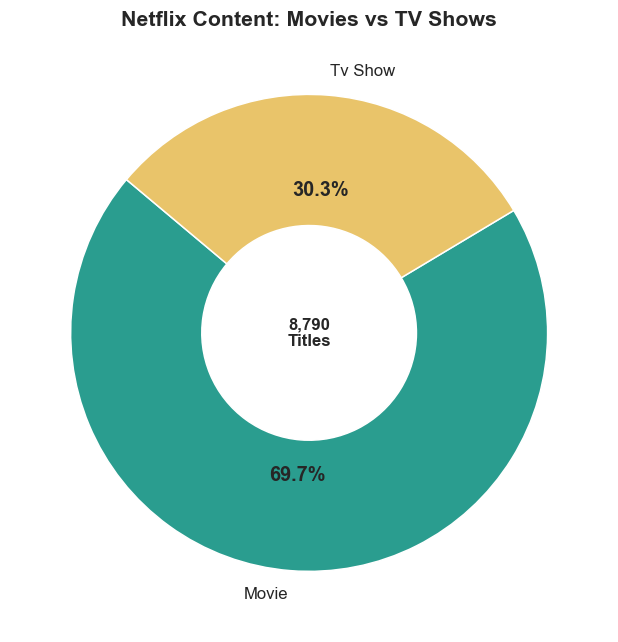

In [25]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2a9d8f', '#e9c46a'],
    wedgeprops=dict(width=0.55))

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

centre = plt.Circle((0, 0), 0.35, fc='white')
ax.add_patch(centre)
ax.text(0, 0, f'{len(df):,}\nTitles', ha='center', va='center',
        fontsize=11, fontweight='bold')

ax.set_title('Netflix Content: Movies vs TV Shows',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_type_donut.png')
plt.show()

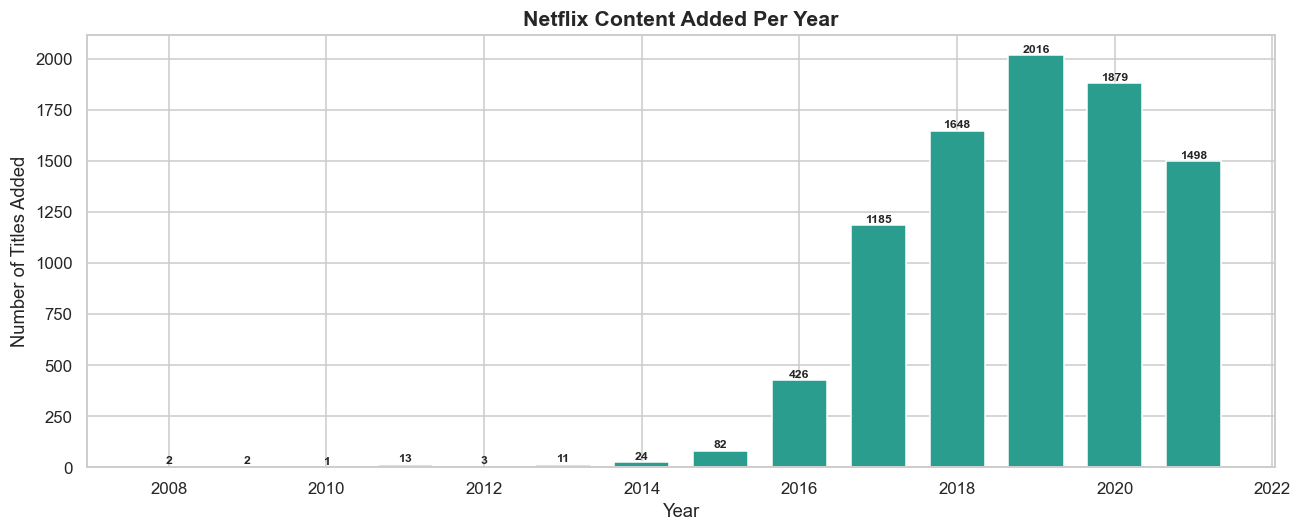

In [26]:
by_year = (df.groupby('year_added')
           .size()
           .sort_index())

fig, ax = plt.subplots()

bars = ax.bar(by_year.index.astype(int), by_year.values,
              color='#2a9d8f', edgecolor='white', width=0.7)

for bar, val in zip(bars, by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 15,
            str(val), ha='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.set_title('Netflix Content Added Per Year', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_content_per_year.png')
plt.show()

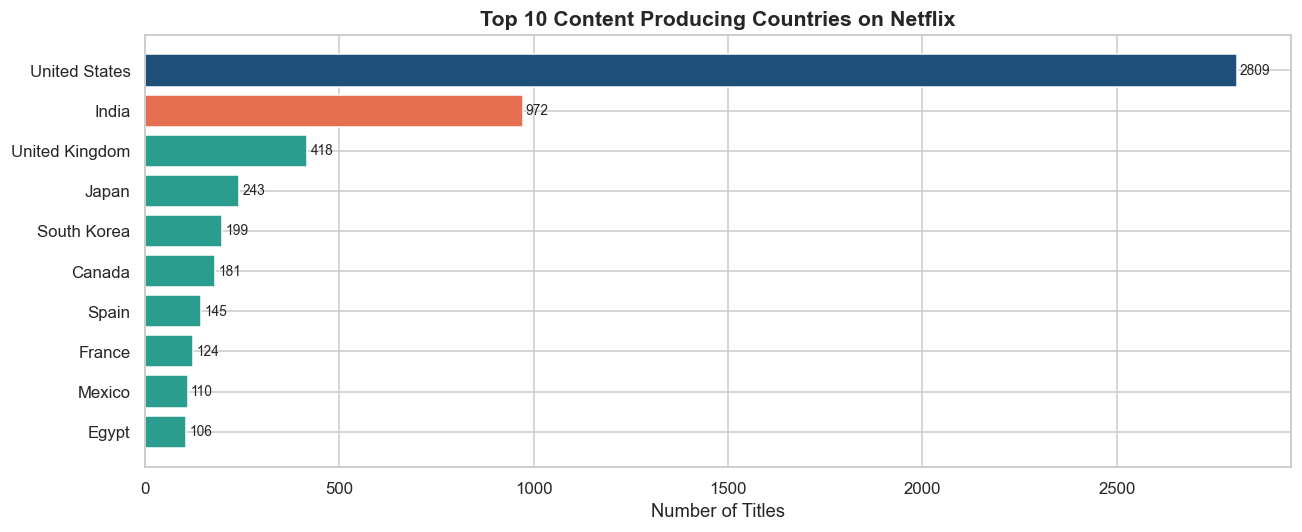

In [27]:
top_c = (df[df['country'] != 'Unknown']['country']
         .value_counts()
         .head(10))

fig, ax = plt.subplots()

colors = ['#1f4e79' if c == 'United States' else
          '#e76f51' if c == 'India' else '#2a9d8f'
          for c in top_c.index]

bars = ax.barh(top_c.index[::-1], top_c.values[::-1], color=colors[::-1])

for bar, val in zip(bars, top_c.values[::-1]):
    ax.text(val + 8, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of Titles')
ax.set_title('Top 10 Content Producing Countries on Netflix',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_top_countries.png')
plt.show()

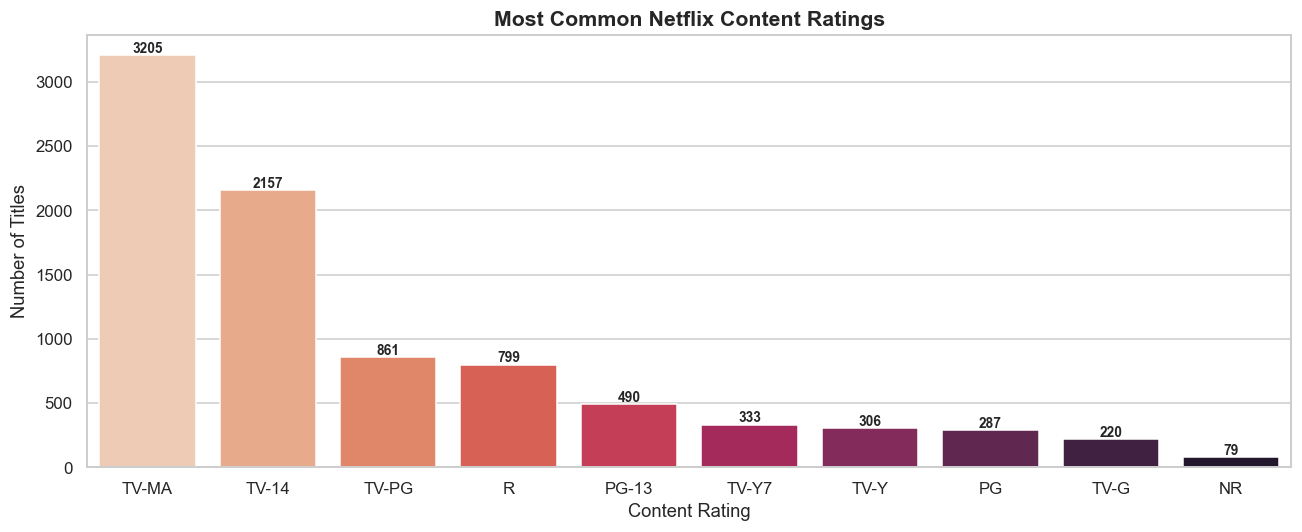

In [28]:
rating_counts = df['rating'].value_counts().head(10)

fig, ax = plt.subplots()

palette = sns.color_palette('rocket_r', len(rating_counts))
sns.barplot(x=rating_counts.index, y=rating_counts.values,
            palette=palette, ax=ax)

for i, val in enumerate(rating_counts.values):
    ax.text(i, val + 20, str(val), ha='center',
            fontsize=9, fontweight='bold')

ax.set_xlabel('Content Rating')
ax.set_ylabel('Number of Titles')
ax.set_title('Most Common Netflix Content Ratings',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_ratings.png')
plt.show()

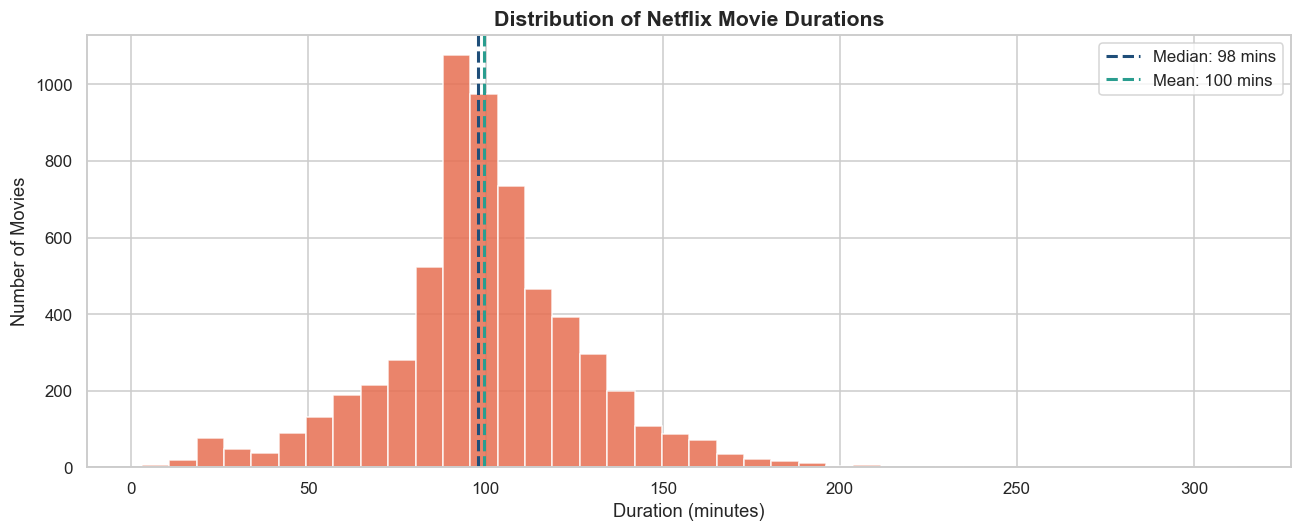

In [29]:
movie_dur = df[df['type'] == 'Movie']['duration_mins'].dropna()

fig, ax = plt.subplots()

ax.hist(movie_dur, bins=40, color='#e76f51', edgecolor='white', alpha=0.85)
ax.axvline(movie_dur.median(), color='#1f4e79', lw=2, ls='--',
           label=f"Median: {movie_dur.median():.0f} mins")
ax.axvline(movie_dur.mean(), color='#2a9d8f', lw=2, ls='--',
           label=f"Mean: {movie_dur.mean():.0f} mins")

ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Movies')
ax.set_title('Distribution of Netflix Movie Durations',
             fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('fig5_movie_duration.png')
plt.show()

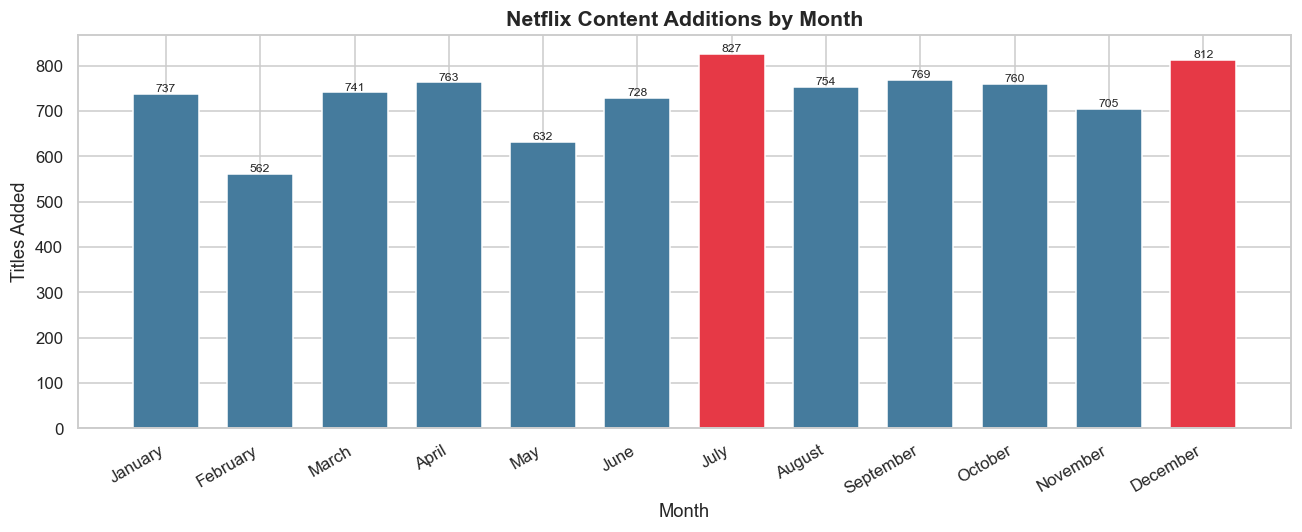

In [30]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_adds = df['month_added'].value_counts().reindex(month_order)

fig, ax = plt.subplots()

colors = ['#e63946' if m in ['July','December'] else '#457b9d'
          for m in month_order]
ax.bar(monthly_adds.index, monthly_adds.values,
       color=colors, edgecolor='white', width=0.7)

for i, val in enumerate(monthly_adds.values):
    ax.text(i, val + 5, str(val), ha='center', fontsize=8)

ax.set_xlabel('Month')
ax.set_ylabel('Titles Added')
ax.set_title('Netflix Content Additions by Month',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig6_monthly_additions.png')
plt.show()

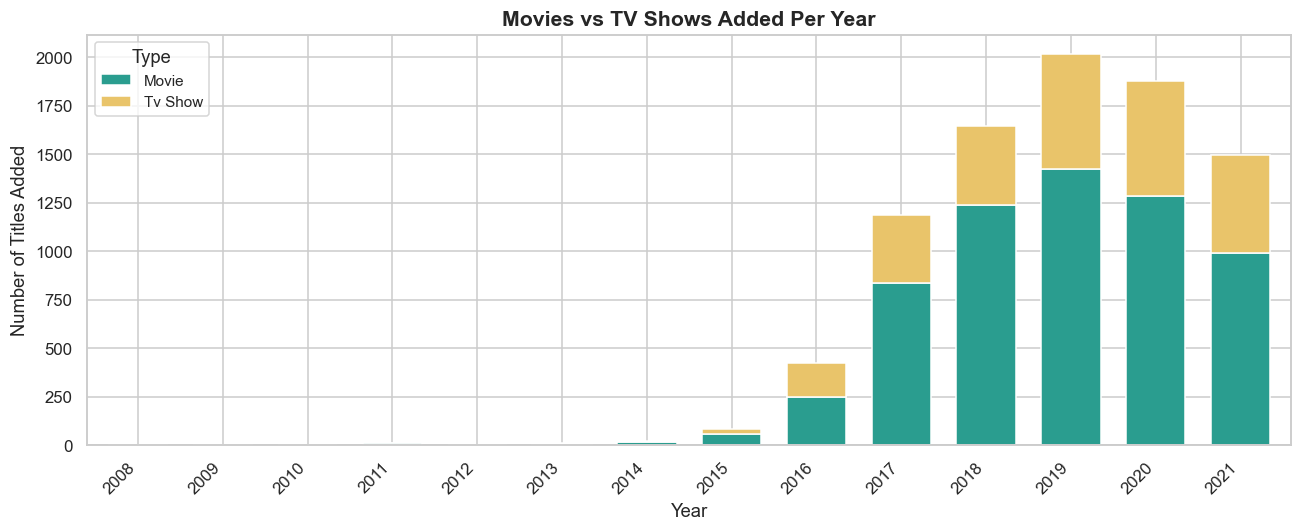

In [31]:
type_year = (df.groupby(['year_added', 'type'])
             .size()
             .unstack(fill_value=0)
             .sort_index())

fig, ax = plt.subplots()

type_year.plot(kind='bar', stacked=True, ax=ax,
               color=['#2a9d8f', '#e9c46a'],
               edgecolor='white', width=0.7)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.set_title('Movies vs TV Shows Added Per Year',
             fontsize=14, fontweight='bold')
ax.legend(title='Type', fontsize=10)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('fig7_type_by_year.png')
plt.show()

# Task 5 — Key Insights

## Insight 1 — Netflix is Primarily a Movie Platform, But TV is the Growth Story
Movies make up 69.7% of all content, but the stacked bar chart tells a more 
important story — TV Show additions have grown as a share of new content every 
year since 2016. In 2019, TV Shows made up 29% of additions. By 2021 that rose 
to 34%. Serialised content keeps subscribers watching longer and reduces 
cancellations — Netflix's investment here is clearly deliberate.

## Insight 2 — Content Growth Exploded After 2015
Netflix added just 82 titles in 2015. By 2019 that number had grown to 2,016 
— a 25x increase in just 4 years. This dramatic ramp-up aligns with Netflix's 
global expansion into new markets and its heavy investment in original 
productions. The slight drop in 2020 and 2021 may reflect production 
slowdowns during the COVID-19 pandemic.

## Insight 3 — The Platform Targets Adult Audiences
TV-MA (3,205 titles) and TV-14 (2,157 titles) together account for 61% of 
all content. Children and family content — TV-Y, TV-Y7, G and PG combined 
— represents less than 15% of the catalogue. Netflix is not primarily a 
family platform. Any strategy targeting younger audiences would require 
a significant shift in content investment.

## Insight 4 — USA Dominates but Local Content is a Global Strategy
The USA produces 2,809 titles — nearly 3x more than India in second place. 
However the presence of South Korea (199), Japan (243), Spain (145) and 
Egypt (106) in the top 10 shows Netflix deliberately investing in 
local-language originals. Each country's content attracts subscribers 
in that market. K-Drama content from South Korea in particular has 
become a global phenomenon driving subscriptions far beyond Korea itself.

## Insight 5 — Netflix Favours Standard Length Films
The median movie runtime is 98 minutes with the mean at 100 minutes — 
and they sit almost on top of each other in the histogram. This tells us 
movie lengths are very consistently distributed around the 90–110 minute 
sweet spot. Very few films exceed 150 minutes. This is not accidental — 
Netflix curates for accessibility, optimising for viewers watching on 
any device in a single sitting.